In [225]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.style
import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.cm as cmx
mpl.style.use('classic')

import baraffe_tables
from baraffe_tables.table_search import baraffe_table_search

from astropy.table import Table
from astropy import units as u
from astropy.constants import G

import mesa_helper as mh
import os
import shutil

%matplotlib inline

In [226]:
mJtomSun = u.jupiterMass.to(u.solMass)
mJtoGrams = u.jupiterMass.to(u.g)

rJtorSun = u.jupiterRad.to(u.solRad)
rSuntorJ = u.solRad.to(u.jupiterRad)
rJtoCm = u.jupiterRad.to(u.cm)

#print(mJtomSun)
print(20.0*mJtoGrams)
#print(rJtorSun)
print(2*rJtoCm)


3.796249194672101e+31
14298400000.0


In [249]:
#eos_choices = ['MESA_default','CD21+AQUA_orig_meos_implementation','CMS19_orig_meos_implementation','CMS19_TC_s=1','CMS19_control_s=1_sf=0.05','CMS19_control_s=1_sf=0.1','CMS19_control_s=1_sf=0.25','CMS19_TC_s=2','CMS19_control_s=2_sf=0.05','CMS19_control_s=2_sf=0.1','CMS19_control_s=2_sf=0.25','CMS19_TC_s=5','CMS19_control_s=5_sf=0.05','CMS19_control_s=5_sf=0.1','CMS19_control_s=5_sf=0.25']

#eos_choices = ['MESA_default','CD21+AQUA_orig_meos_implementation','CMS19_orig_meos_implementation','CMS19_TC_s=2','CMS19_control_s=2_sf=0.1','CMS19_control_s=2_sf=0.25']
eos_choices = ['MESA_default','CMS19_orig_meos_implementation','CMS19_TC_s=2','CMS19_control_s=2_sf=0.25']
labels = ['SCVH/OPAL', 'M22/CMS19 +\nZ blend', 'F-derived', 'control']
posterlabels=['MESA default','original EOS', 'F-derived EOS', 'control']
#eos_choices = ['CMS19_control_s=2_sf=0.1','CMS19_control_s=2_sf=0.25']

#eos_choices = ['MESA_default','CMS19_orig_meos_implementation','CMS19_TC_s=1','CMS19_control_s=1_sf=0.25']
#eos_choices = ['MESA_default','CMS19_orig_meos_implementation','CD21+AQUA_orig_meos_implementation','CMS19_TC_s=1']
#eos_choices = ['CMS19_TC_s=1']

#colors = ['k','m','b','g','g','g','g','y','y','y','y','m','m','m','m']
#ls = ['-','-','-','-','--','-.',':','-','--','-.',':','-','--','-.',':']

#colors=['k','b','r','r']
#ls=['-','-','-',':']
print(eos_choices)

comps = ['protosolar','']
#Minit = np.array((20.0,10.0,7.5,6.0,5.0,4.0,3.0,2.0))
#Minit = np.array((12.0,10.0,5.0,2.0,1.5))#,1.0))
#Minit = np.array((10.0,7.5,5.0,4.0,3.0,2.0))#,1.5))#,1.0))
Minit = np.array((10.0,5.0,2.0))

Rinit = np.atleast_1d(np.array((2.0)))

#comps = ['platowg']
#Minit = np.atleast_1d(np.array((1.0)))
testcolors = ['k','b','y','y','r','y']
ls = ['--','-','-','--']
#testcolors=['r','y']

['MESA_default', 'CMS19_orig_meos_implementation', 'CMS19_TC_s=2', 'CMS19_control_s=2_sf=0.25']


no MESA_default
no mespa for 1.5


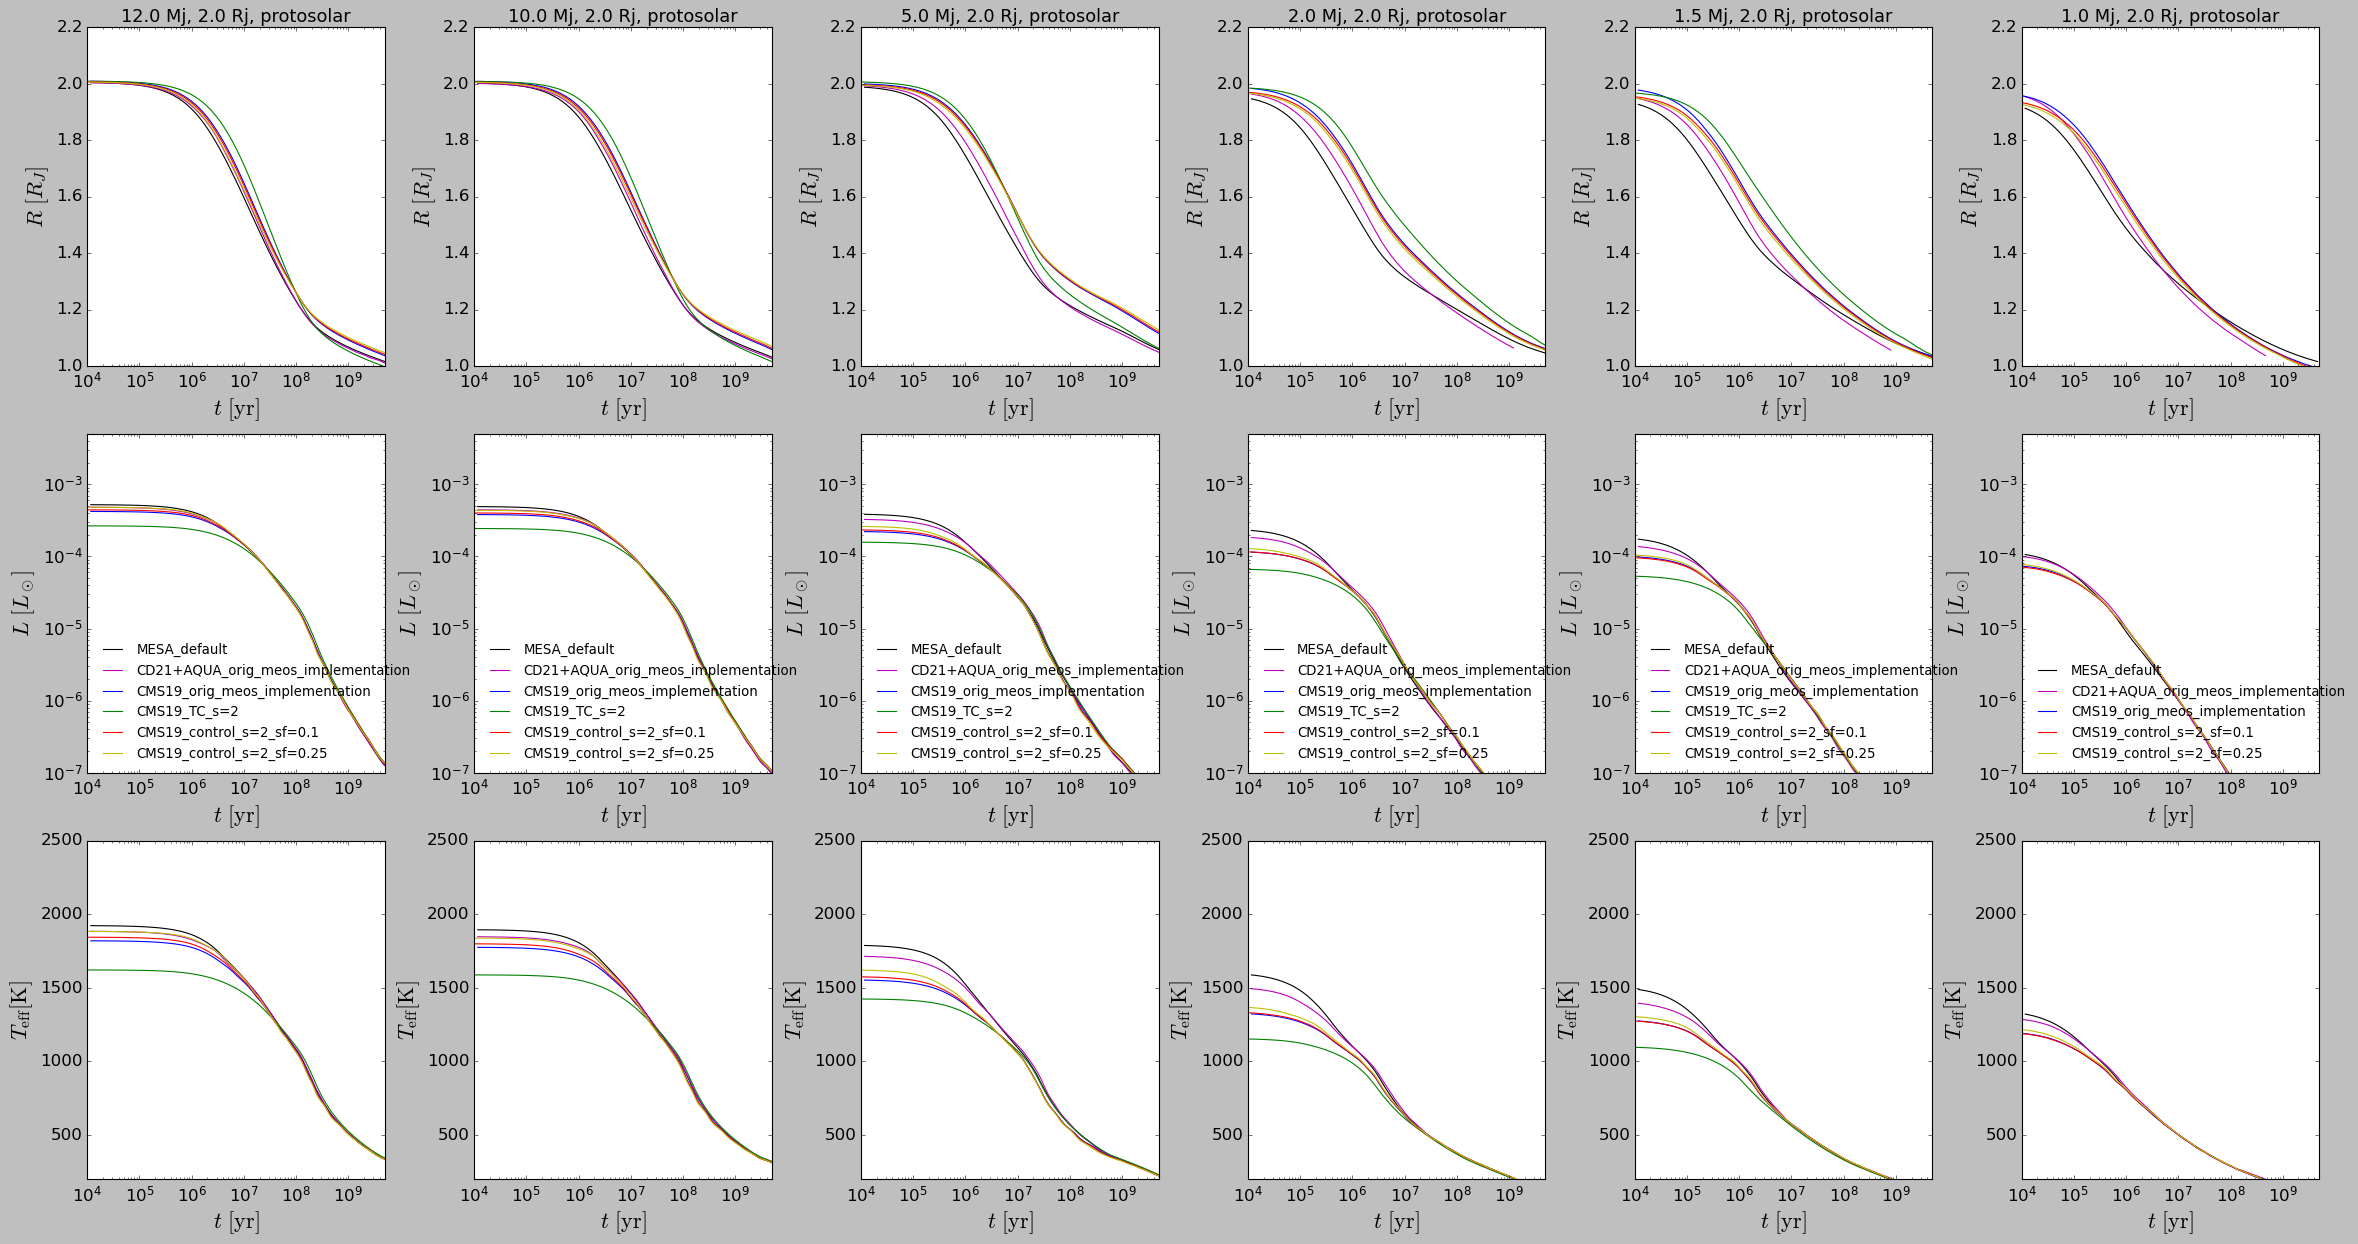

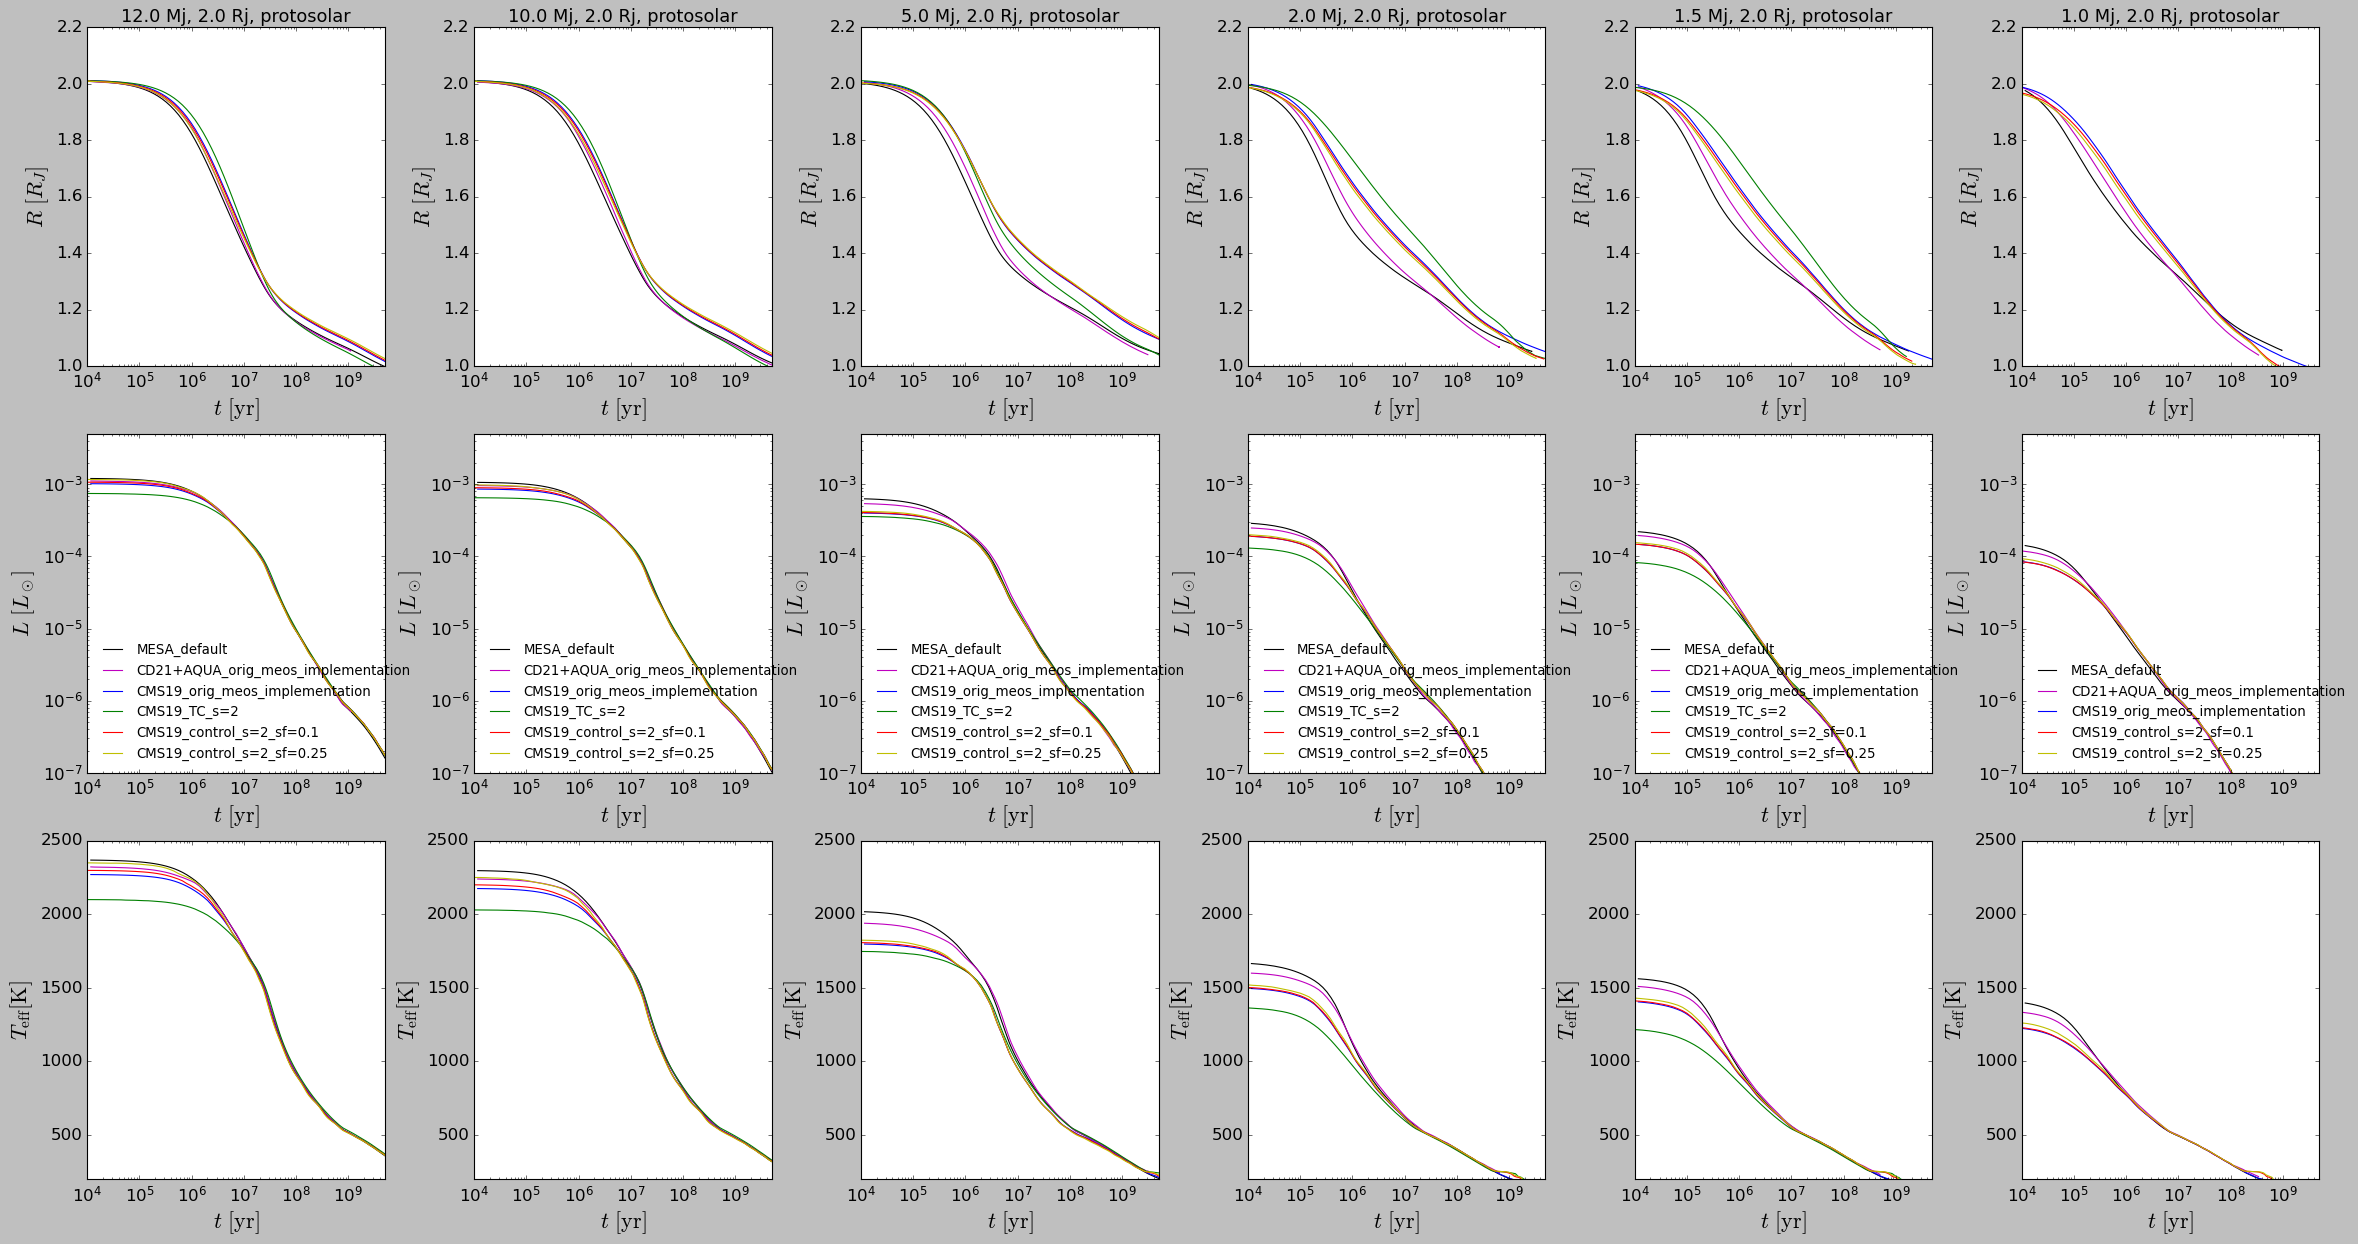

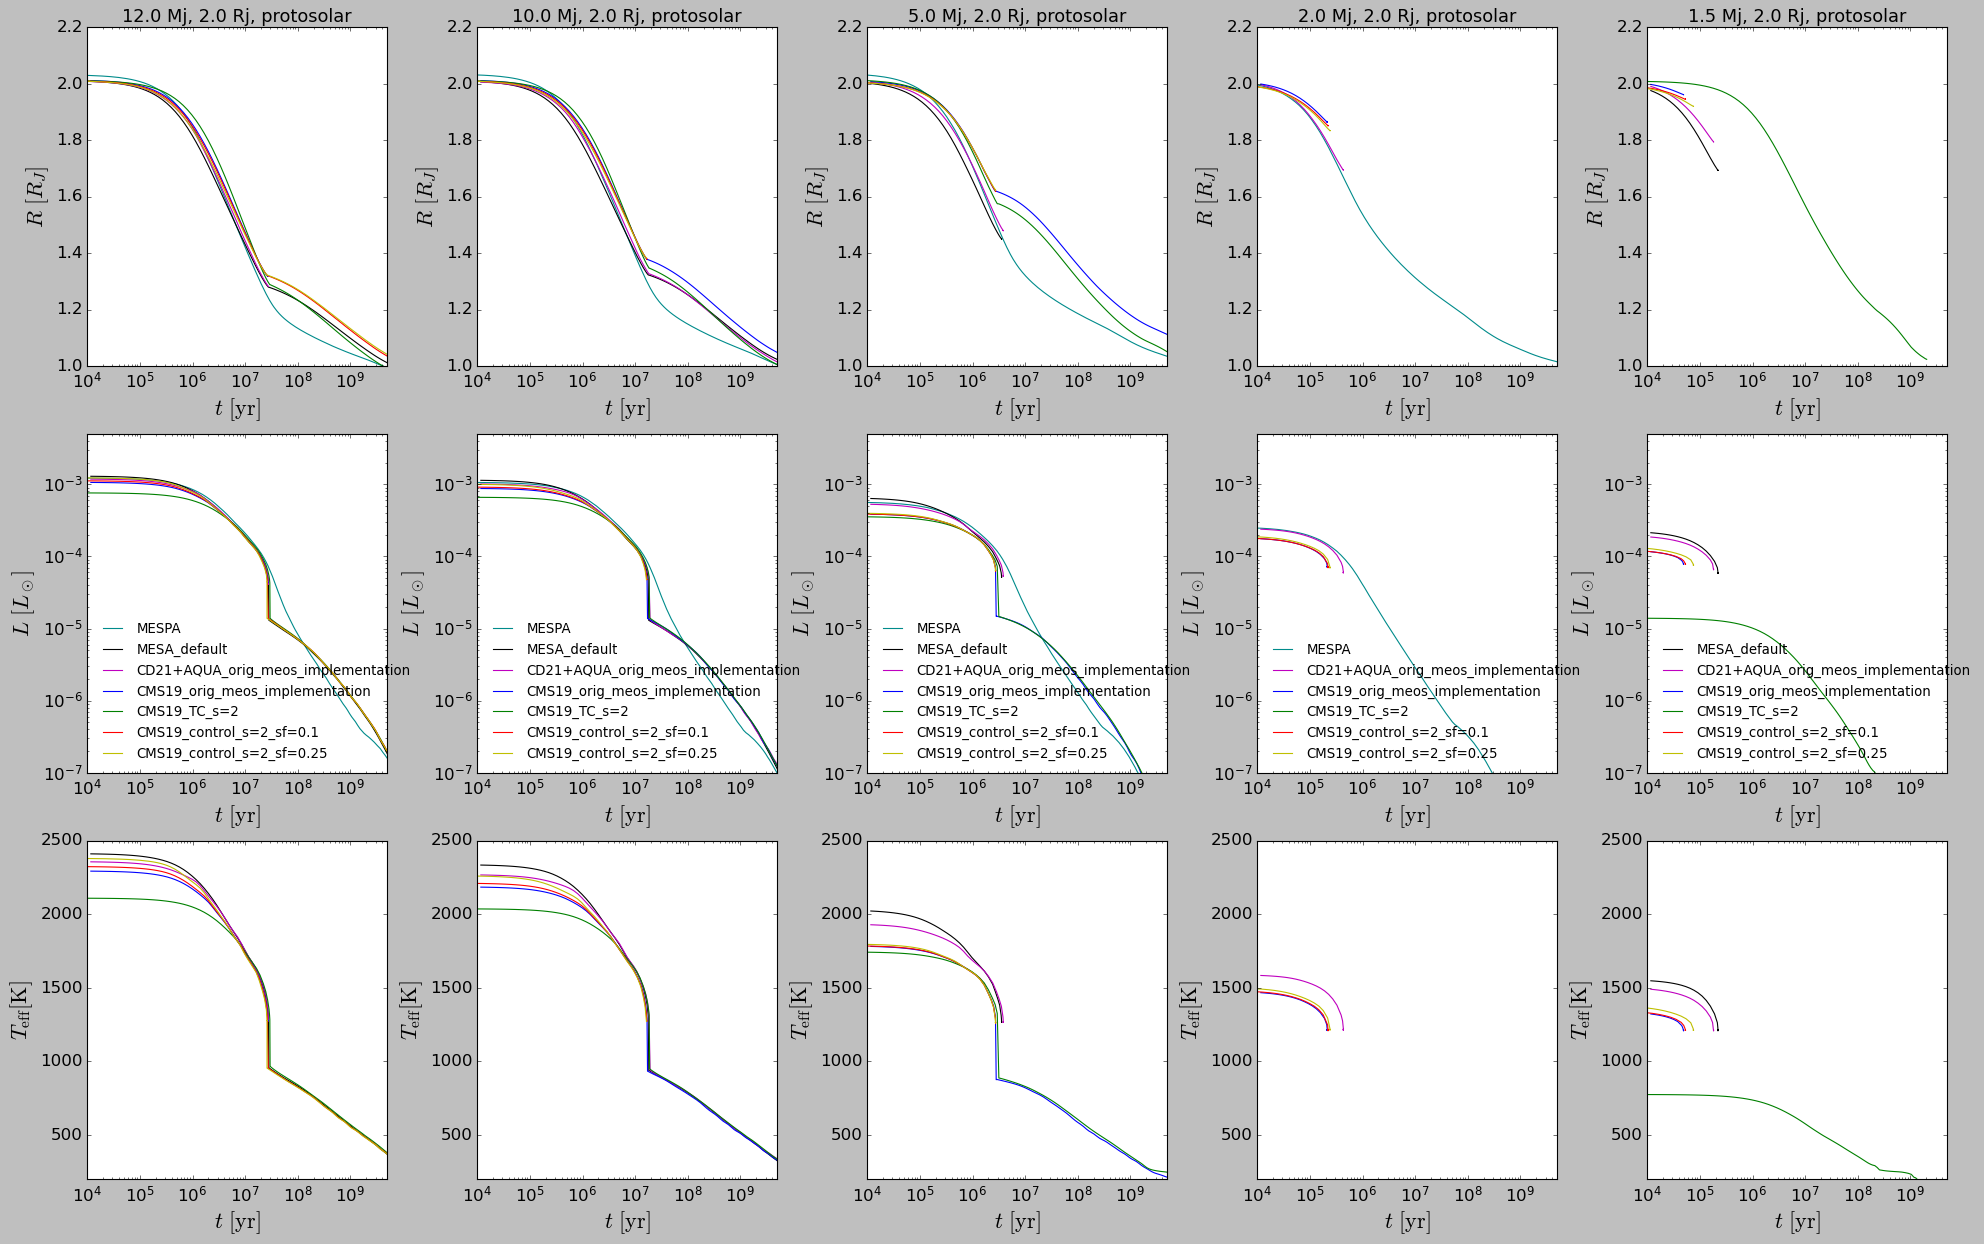

In [43]:
#fig, axes = plt.subplots(3,len(Minit),figsize=(24,16))
fig, axes = plt.subplots(3,len(Minit),figsize=(6*len(Minit),6*3))

for ii in range(len(Minit)):
    axes[0,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
    axes[0,ii].set_ylabel(r"$R\ [R_J]$",fontsize=20)
    axes[1,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
    axes[1,ii].set_ylabel(r"$L\ [L_\odot]$",fontsize=20)
    axes[2,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
    axes[2,ii].set_ylabel(r"$T_{\mathrm{eff}} [\mathrm{K}]$",fontsize=20)
    
    axes[0,ii].set_xscale('log')
    axes[1,ii].set_xscale('log')
    axes[2,ii].set_xscale('log')
    
    axes[1,ii].set_yscale('log')
    #axes[0,ii].set_xlim(1.e7,5.e9)
    axes[0,ii].set_xlim(1.e4,5.e9)
    #axes[0,ii].set_ylim(1.,1.5)
    axes[0,ii].set_ylim(1.,2.2)
    
    #axes[1,ii].set_xlim(1.e7,5.e9)
    axes[1,ii].set_xlim(1.e4,5.e9)
    #axes[1,ii].set_ylim(1.e-7,2.e-4)
    axes[1,ii].set_ylim(1.e-7,5.e-3)

    #axes[2,ii].set_xlim(1.e7,5.e9)
    axes[2,ii].set_xlim(1.e4,5.e9)
    #axes[2,ii].set_ylim(200,1800)
    axes[2,ii].set_ylim(200,2500)
    
    #axes[2,ii].invert_yaxis()

for ax in np.ravel(axes):
    ax.tick_params(axis='both', which='major', labelsize=15)

for j, m in enumerate(Minit):
    for k, comp in enumerate(comps[0:1]):
        for l, r in enumerate(Rinit[0:1]):
            axes[0,j].set_title("{0} Mj, {1} Rj, {2}".format(m,r,comp),fontsize=16)
            try:     
                history_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/LOGS/planet_5.0Gyr_{0}_Mj_{1}_Rj_{2}_mespa.history".format(m,r,comp)
                
                history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
            
                axes[0,j].plot(history['star_age'],history['radius']*rSuntorJ,color='#008B8B',ls='-')
                axes[1,j].plot(history['star_age'],history['luminosity'],color='#008B8B',ls='-',label='MESPA')
                '''
                profile_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/planet_5.0Gyr_{0}_Mj_{1}_Rj_{2}_mespa.profile".format(m,r,comp)
                
                profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
            
                axes[2,j].plot(profile['logT'],profile['logP']-6,color='#008B8B',ls='-',label='MESPA')
                '''
            except FileNotFoundError:
                print("no mespa for {0}".format(m))
        
            for i,e in enumerate(eos_choices):
    
                try:
                    history_filename = "./eos_{0}/planet_5.0Gyr_{1}_Mj_{2}_Rj_{3}_adiabatic.history".format(e,m,r,comp)
                    history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
        
                    axes[0,j].plot(history['star_age'],history['radius']*rSuntorJ,color=testcolors[i],ls='-')
                    axes[1,j].plot(history['star_age'],history['luminosity'],color=testcolors[i],ls='-',label=e)
                    axes[2,j].plot(history['star_age'],history['Teff'],color=testcolors[i],ls='-')
    
                    #print(e)
                    #print(history['radius']*rSuntorJ)
                    #print(history['luminosity'])
                    '''
                    profile_filename = "./eos_{0}/planet_1.0Gyr_{1}_Mj_{2}.profile".format(e,m,comp)
                    profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
        
                    axes[2,j].plot(profile['logT'],profile['logP']-6,color=colors[i],ls=ls[i],label=e)
                    '''
                    axes[1,j].legend(loc='lower left',frameon=False,fontsize=12)

                except FileNotFoundError:
                    print("no {0}".format(e))

plt.subplots_adjust(hspace=0.2,wspace=0.3)
plt.show()
#plt.savefig("../paper_figures/protosolar_model_grid.pdf",bbox_inches='tight')

In [101]:
#fig, axes = plt.subplots(3,len(Minit),figsize=(24,16))
fig, axes = plt.subplots(3,len(Minit),figsize=(6*len(Minit),6*3))

for ii in range(len(Minit)):
    axes[0,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
    axes[0,ii].set_ylabel(r"$R\ [R_J]$",fontsize=20)
    axes[1,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
    axes[1,ii].set_ylabel(r"$L\ [L_\odot]$",fontsize=20)
    axes[2,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
    axes[2,ii].set_ylabel(r"$T_{\mathrm{eff}} [\mathrm{K}]$",fontsize=20)
    
    axes[0,ii].set_xscale('log')
    axes[1,ii].set_xscale('log')
    axes[2,ii].set_xscale('log')
    
    axes[1,ii].set_yscale('log')
    #axes[0,ii].set_xlim(1.e7,5.e9)
    axes[0,ii].set_xlim(1.e4,5.e9)
    #axes[0,ii].set_ylim(1.,1.5)
    axes[0,ii].set_ylim(1.,2.2)
    
    #axes[1,ii].set_xlim(1.e7,5.e9)
    axes[1,ii].set_xlim(1.e4,5.e9)
    #axes[1,ii].set_ylim(1.e-7,2.e-4)
    axes[1,ii].set_ylim(1.e-7,5.e-3)

    #axes[2,ii].set_xlim(1.e7,5.e9)
    axes[2,ii].set_xlim(1.e4,5.e9)
    #axes[2,ii].set_ylim(200,1800)
    axes[2,ii].set_ylim(200,2500)
    
    #axes[2,ii].invert_yaxis()

for ax in np.ravel(axes):
    ax.tick_params(axis='both', which='major', labelsize=15)

for j, m in enumerate(Minit):
    for k, comp in enumerate(comps[0:1]):
        for l, r in enumerate(Rinit[0:1]):
            axes[0,j].set_title("{0} Mj, {1} Rj, {2}".format(m,r,comp),fontsize=16)
            try:     
                history_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/LOGS/planet_5.0Gyr_{0}_Mj_{1}_Rj_{2}_mespa.history".format(m,r,comp)
                
                history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
            
                #axes[0,j].plot(history['star_age'],history['radius']*rSuntorJ,color='#008B8B',ls='-')
                #axes[1,j].plot(history['star_age'],history['luminosity'],color='#008B8B',ls='-',label='MESPA')
                '''
                profile_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/planet_5.0Gyr_{0}_Mj_{1}_Rj_{2}_mespa.profile".format(m,r,comp)
                
                profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
            
                axes[2,j].plot(profile['logT'],profile['logP']-6,color='#008B8B',ls='-',label='MESPA')
                '''
            except FileNotFoundError:
                print("no mespa for {0}".format(m))
        
            for i,e in enumerate(eos_choices):
    
                try:
                    history_filename = "./eos_{0}/planet_5.0Gyr_{1}_Mj_{2}_Rj_{3}.history".format(e,m,r,comp)
                    history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
        
                    axes[0,j].plot(history['star_age'],history['radius']*rSuntorJ,color=testcolors[i],ls='-')
                    axes[1,j].plot(history['star_age'],history['luminosity'],color=testcolors[i],ls='-',label=e)
                    axes[2,j].plot(history['star_age'],history['Teff'],color=testcolors[i],ls='-')
    
                    #print(e)
                    #print(history['radius']*rSuntorJ)
                    #print(history['luminosity'])
                    '''
                    profile_filename = "./eos_{0}/planet_1.0Gyr_{1}_Mj_{2}.profile".format(e,m,comp)
                    profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
        
                    axes[2,j].plot(profile['logT'],profile['logP']-6,color=colors[i],ls=ls[i],label=e)
                    '''
                    axes[1,j].legend(loc='lower left',frameon=False,fontsize=12)

                except FileNotFoundError:
                    print("no {0} at {1}".format(e, m))

plt.subplots_adjust(hspace=0.2,wspace=0.3)
#plt.show()
plt.savefig("../paper_figures/protosolar_model_grid.pdf",bbox_inches='tight')

no mespa for 1.5


In [228]:
import EOSutils as meos
import copy

# add a panel to results figure showing where the planets are
compstr = 'protosolar'
XX = 0.706
YY = 0.277
ZZ = 0.017

orig_tabulated_QT = meos.read_MESAtable("../../meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend_{0}.data".format(compstr))

orig_tabulated_rhoT, orig_tabulated = meos.reshapeQTgrid(orig_tabulated_QT,lower_logRho_bound=-8,upper_logRho_bound=6,rounding=2)
orig_tabulated.X = XX
orig_tabulated.Y = YY
orig_tabulated.Z = ZZ
orig_tabulated.compute_atomic_number()

TC_tabulated_QT = meos.read_MESAtable("../../meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-TC_s=2_{0}.data".format(compstr))

TC_tabulated_rhoT, TC_tabulated = meos.reshapeQTgrid(TC_tabulated_QT,lower_logRho_bound=-8,upper_logRho_bound=6,rounding=2)
TC_tabulated.X = XX
TC_tabulated.Y = YY
TC_tabulated.Z = ZZ
TC_tabulated.compute_atomic_number()

grid_T = orig_tabulated.log10Tgrid[0] #np.arange(2.,8.04,0.05)
grid_rho = orig_tabulated.log10rhogrid[:,0] #np.arange(-8.,6.04,0.05)
    
meshgrid_T, meshgrid_rho = np.meshgrid(grid_T, grid_rho, indexing='xy')

cmap = copy.copy(mpl.cm.get_cmap("coolwarm"))
#cmap.set_over('#A1212A')
#cmap.set_under('#2A337E')
cmap.set_over('#B40426')
cmap.set_under('#3B4CC0')
cmap.set_bad('grey')

/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_93597/2318327652.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("coolwarm"))


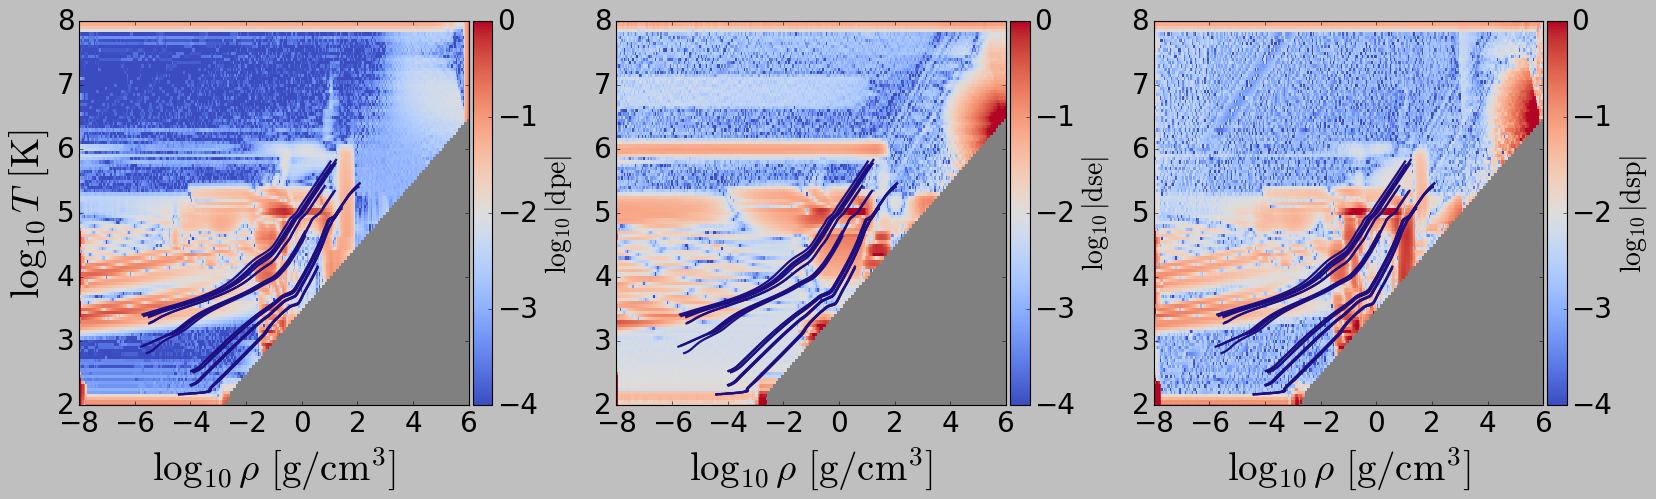

[[-12.893744176017272 -5.2716250028787295 0.6427146552668574 ...
  -0.03292871807844111 -0.06942284216299477 -0.09456623833440558]
 [196.26733112552648 135.63887666864207 85.98414797343725 ...
  -0.031770615786141154 -0.060335756788860384 -0.09279918834076484]
 [0.29762723526081736 0.44500961605961264 0.5550809853263856 ...
  -0.03232862996728647 -0.06079863578963973 -0.09360282113448859]
 ...
 [-- -- -- ... -0.07056080954708821 -0.07168659591986892
  -0.07594250512160694]
 [-- -- -- ... -0.11820969929787428 -0.11792294332536035
  -0.12057467288594781]
 [-- -- -- ... -0.17532553742264223 -0.17511693082911817
  -0.1779509781807559]]


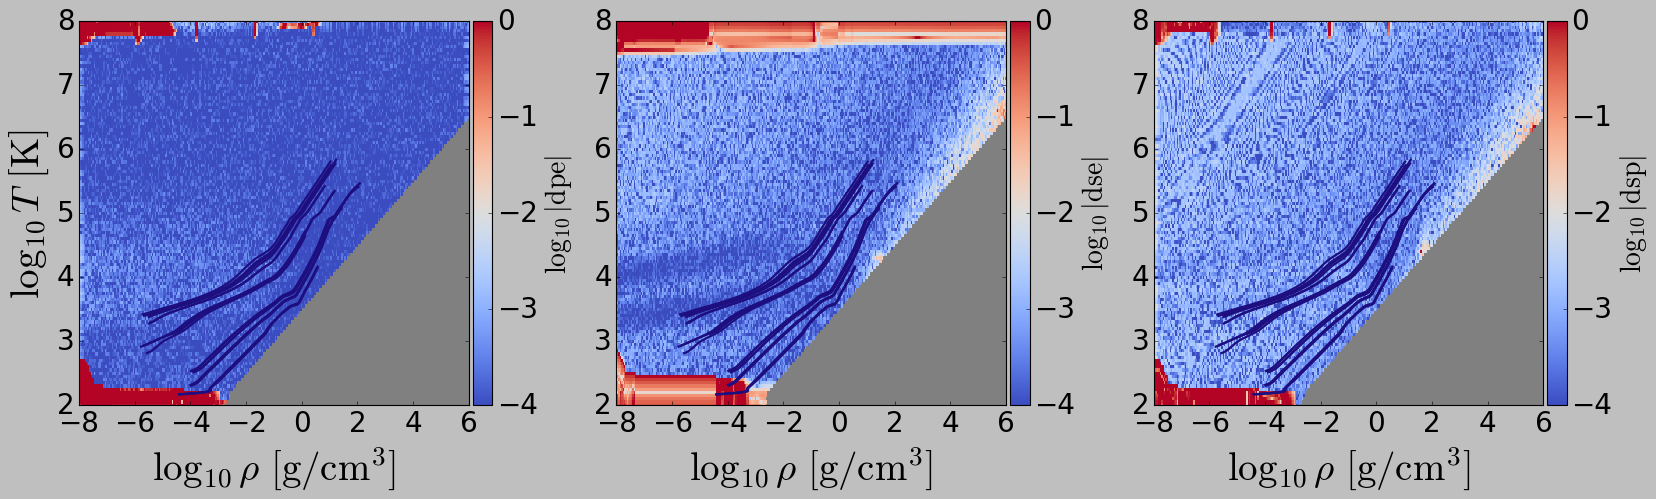

In [229]:
orig_tabulated_dpe, orig_tabulated_dse, orig_tabulated_dsp, orig_tabulated_a, orig_tabulated_b, orig_tabulated_c = meos.consistency_metrics(orig_tabulated, P=10**orig_tabulated.log10Pgrid,S=10**orig_tabulated.log10Sgrid,E=10**orig_tabulated.log10Egrid,species='H',maskUnphysicalRegion=True,paperplot=True,plot_tracks=True)
print(orig_tabulated_dpe)

TC_tabulated_dpe, TC_tabulated_dse, TC_tabulated_dsp, TC_tabulated_a, TC_tabulated_b, TC_tabulated_c = meos.consistency_metrics(TC_tabulated, P=10**TC_tabulated.log10Pgrid,S=10**TC_tabulated.log10Sgrid,E=10**TC_tabulated.log10Egrid,species='H',maskUnphysicalRegion=True,paperplot=True,plot_tracks=True)


In [250]:
fig, axes = plt.subplots(3,len(Minit),figsize=(6*len(Minit),6*3))
#fig, axes = plt.subplots(5,len(Minit),figsize=(6*len(Minit),6*5))
#fig, axes = plt.subplots(2,len(Minit),figsize=(6*len(Minit),6*2))

for ii in range(len(Minit)):
    if ii==0:
        #axes[0,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
        axes[0,ii].set_ylabel(r"$R\ [R_J]$",fontsize=35)
        #axes[1,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
        #axes[1,ii].set_ylabel(r"$L\ [L_\odot]$",fontsize=35)
        axes[1,ii].set_ylabel(r"$T_{\mathrm{eff}} [\mathrm{K}]$",fontsize=35)
        axes[2,ii].set_ylabel(r"$T_{\mathrm{eff}}\ \mathrm{fractional\ diff.}$",fontsize=35)

    axes[2,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=35)
    
    axes[0,ii].set_xscale('log')
    axes[1,ii].set_xscale('log')
    
    
    #axes[1,ii].set_yscale('log')
    
    #axes[0,ii].set_xlim(1.e4,5.e9)
    #axes[0,ii].set_ylim(0.95,2.1)

    axes[0,ii].set_xlim(1.e7,5.e9)
    axes[0,ii].set_ylim(0.95,1.7)
    
    #axes[1,ii].set_xlim(1.e4,5.e9)
    #axes[1,ii].set_ylim(8.e-8,1.e-3)

    #axes[1,ii].set_xlim(1.e4,5.e9)
    #axes[1,ii].set_ylim(200,2000)

    axes[1,ii].set_xlim(1.e7,5.e9)
    axes[1,ii].set_ylim(100,1450)
    axes[1,ii].set_yticks(np.arange(200,1500,200))

    axes[2,ii].set_xscale('log')
    axes[2,ii].set_xlim(1.e7,5.e9)
    axes[2,ii].set_ylim(-0.1,0.1)

    '''
    axes[2,ii].set_xscale('log')
    axes[2,ii].set_xlim(1.e7,5.e9)
    axes[2,ii].set_ylim(1.e-10,1.e-4)
    axes[2,ii].set_yscale('log')
    '''
    
    #axes[2,ii].invert_yaxis()
    axes[0,ii].set_xticklabels([])
    axes[1,ii].set_xticklabels([])

for ax in np.ravel(axes):
    ax.tick_params(axis='both', which='major', labelsize=15)

for j, m in enumerate(Minit):
    for k, comp in enumerate(comps[0:1]):
        for l, r in enumerate(Rinit[0:1]):
            axes[0,j].set_title(r"{0} $M_J$".format(m),fontsize=35)
            try:     
                history_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/LOGS/planet_5.0Gyr_{0}_Mj_{1}_Rj_{2}_mespa.history".format(m,r,comp)
                
                history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
            
                #axes[0,j].plot(history['star_age'],history['radius']*rSuntorJ,color='#008B8B',ls='-')
                #axes[1,j].plot(history['star_age'],history['luminosity'],color='#008B8B',ls='-',label='MESPA')
                '''
                profile_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/planet_5.0Gyr_{0}_Mj_{1}_Rj_{2}_mespa.profile".format(m,r,comp)
                
                profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
            
                axes[2,j].plot(profile['logT'],profile['logP']-6,color='#008B8B',ls='-',label='MESPA')
                '''
            except FileNotFoundError:
                print("no mespa for {0}".format(m))
        
            for i,e in enumerate(eos_choices):
    
                try:
                    history_filename = "./eos_{0}/planet_5.0Gyr_{1}_Mj_{2}_Rj_{3}_simplifiedguillot.history".format(e,m,r,comp)
                    history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
        
                    axes[0,j].plot(history['star_age'],history['radius']*rSuntorJ,color=testcolors[i],ls=ls[i],label=labels[i],lw=2)
                    #axes[1,j].plot(history['star_age'],history['luminosity'],color=testcolors[i],ls=ls[i],label=labels[i],lw=2)
                    axes[1,j].plot(history['star_age'],history['Teff'],color=testcolors[i],ls=ls[i],label=labels[i],lw=2)

                    default_history_filename = "./eos_CMS19_orig_meos_implementation/planet_5.0Gyr_{1}_Mj_{2}_Rj_{3}_simplifiedguillot.history".format(e,m,r,comp)
                    default_history = Table.read(default_history_filename, format="ascii", header_start=4, data_start=5)

                    interp_thisEOS_Teff = np.interp(np.log10(default_history['star_age']), np.log10(history['star_age']), history['Teff'])
                    #interp_thisEOS_Teff = np.interp(default_history['star_age'], history['star_age'], history['Teff'])
                    axes[2,j].plot(default_history['star_age'], (interp_thisEOS_Teff - default_history['Teff'])/default_history['Teff'], color=testcolors[i],ls=ls[i],label=labels[i],lw=2)
                    #axes[2,j].plot(history['star_age'],history['luminosity'],color=testcolors[i],ls=ls[i],label=labels[i],lw=2)
    
                    #print(e)
                    #print(history['radius']*rSuntorJ)
                    #print(history['luminosity'])
                    '''
                    profile_filename = "./eos_{0}/planet_1.0Gyr_{1}_Mj_{2}.profile".format(e,m,comp)
                    profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
        
                    axes[2,j].plot(profile['logT'],profile['logP']-6,color=colors[i],ls=ls[i],label=e)
                    '''
                    #axes[1,j].legend(loc='lower left',frameon=False,fontsize=20)

                except FileNotFoundError:
                    print("no {0} at {1}".format(e, m))

axes[0,0].legend(loc='upper right',frameon=False,fontsize=19)


'''
for j, m in enumerate(Minit):
    #axes[2,j].pcolormesh(meshgrid_rho, meshgrid_T, orig_tabulated_dpe, cmap=cmap, shading='nearest',vmin=-0.5,vmax=0.5)
    #axes[3,j].pcolormesh(meshgrid_rho, meshgrid_T, orig_tabulated_dse, cmap=cmap, shading='nearest',vmin=-0.5,vmax=0.5)
    #axes[4,j].pcolormesh(meshgrid_rho, meshgrid_T, orig_tabulated_dsp, cmap=cmap, shading='nearest',vmin=-0.5,vmax=0.5)
    
    axes[2,j].pcolormesh(meshgrid_rho, meshgrid_T, np.log10(np.abs(orig_tabulated_dpe)), cmap=cmap, shading='nearest',vmin=-4,vmax=0)
    axes[3,j].pcolormesh(meshgrid_rho, meshgrid_T, np.log10(np.abs(orig_tabulated_dse)), cmap=cmap, shading='nearest',vmin=-4,vmax=0)
    axes[4,j].pcolormesh(meshgrid_rho, meshgrid_T, np.log10(np.abs(orig_tabulated_dsp)), cmap=cmap, shading='nearest',vmin=-4,vmax=0)

    for k, comp in enumerate(comps[0:1]):
        for l, r in enumerate(Rinit[0:1]):
            for i,e in enumerate(eos_choices[0:1]):
                try:
                    create_profile_filename = "./make_initial_models/planet_create_{0}_Mj_{1}_Rj_protosolar_{2}.profile".format(m,r,e)
                    create_profile = Table.read(create_profile_filename, format="ascii", header_start=4, data_start=5)
                    evolve_profile_filename = "./eos_{0}/planet_{1}_Mj_{2}_Rj_{3}_simplifiedguillot.terminationprofile".format(e,m,r,comp)
                    evolve_profile = Table.read(evolve_profile_filename, format="ascii", header_start=4, data_start=5)
    
                    axes[2,j].plot(create_profile['logRho'],create_profile['logT'],'r-',lw=3)
                    axes[2,j].plot(evolve_profile['logRho'],evolve_profile['logT'],'b-',lw=3)

                    axes[3,j].plot(create_profile['logRho'],create_profile['logT'],'r-',lw=3)
                    axes[3,j].plot(evolve_profile['logRho'],evolve_profile['logT'],'b-',lw=3)

                    axes[4,j].plot(create_profile['logRho'],create_profile['logT'],'r-',lw=3)
                    axes[4,j].plot(evolve_profile['logRho'],evolve_profile['logT'],'b-',lw=3)
                    #print(len(create_profile['logRho']))
                    #print(len(evolve_profile['logRho']))
                    #print("")
                    
                   
                except FileNotFoundError:
                    print("no {0} at {1}".format(e, m))

for ax in np.ravel(axes[2:]):
    ax.set_xlim(-8,6)
    ax.set_ylim(2,8)

axes[2,0].set_xlabel('dpe')
axes[3,0].set_xlabel('dse')
axes[4,0].set_xlabel('dsp')

'''   
axes[0,0].legend(loc='upper right',frameon=False,fontsize=19)


for ax in np.ravel(axes):
    ax.tick_params(axis='both', which='major', labelsize=25)


plt.subplots_adjust(hspace=0.05,wspace=0.3)
#plt.show()
plt.savefig("../paper_figures/protosolar_model_grid_simplifiedguillot.pdf",bbox_inches='tight')

In [251]:
fig, axes = plt.subplots(3,len(Minit),figsize=(6*len(Minit),6*3))
#fig, axes = plt.subplots(5,len(Minit),figsize=(6*len(Minit),6*5))
#fig, axes = plt.subplots(2,len(Minit),figsize=(6*len(Minit),6*2))

for ii in range(len(Minit)):
    if ii==0:
        #axes[0,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
        axes[0,ii].set_ylabel(r"$R\ [R_J]$",fontsize=35)
        #axes[1,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
        #axes[1,ii].set_ylabel(r"$L\ [L_\odot]$",fontsize=35)
        axes[1,ii].set_ylabel(r"$L\ [\mathrm{L}_\odot]$",fontsize=35)
        axes[2,ii].set_ylabel(r"$L\ \mathrm{fractional\ diff.}$",fontsize=35)

    axes[2,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=35)
    
    axes[0,ii].set_xscale('log')
    axes[1,ii].set_xscale('log')
    
    
    #axes[1,ii].set_yscale('log')
    
    #axes[0,ii].set_xlim(1.e4,5.e9)
    #axes[0,ii].set_ylim(0.95,2.1)

    axes[0,ii].set_xlim(1.e7,5.e9)
    axes[0,ii].set_ylim(0.95,1.7)
    
    #axes[1,ii].set_xlim(1.e4,5.e9)
    #axes[1,ii].set_ylim(8.e-8,1.e-3)

    #axes[1,ii].set_xlim(1.e4,5.e9)
    #axes[1,ii].set_ylim(200,2000)

    axes[1,ii].set_xlim(1.e7,5.e9)
    #axes[1,ii].set_ylim(100,1450)
    #axes[1,ii].set_yticks(np.arange(200,1500,200))
    axes[1,ii].set_ylim(1.e-9,1.5e-4)
    axes[1,ii].set_yscale('log')

    axes[2,ii].set_xscale('log')
    axes[2,ii].set_xlim(1.e7,5.e9)
    axes[2,ii].set_ylim(-0.3,0.3)

    '''
    axes[2,ii].set_xscale('log')
    axes[2,ii].set_xlim(1.e7,5.e9)
    axes[2,ii].set_ylim(1.e-10,1.e-4)
    axes[2,ii].set_yscale('log')
    '''
    
    #axes[2,ii].invert_yaxis()
    axes[0,ii].set_xticklabels([])
    axes[1,ii].set_xticklabels([])

for ax in np.ravel(axes):
    ax.tick_params(axis='both', which='major', labelsize=15)

for j, m in enumerate(Minit):
    for k, comp in enumerate(comps[0:1]):
        for l, r in enumerate(Rinit[0:1]):
            axes[0,j].set_title(r"{0} $M_J$".format(m),fontsize=35)
            try:     
                history_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/LOGS/planet_5.0Gyr_{0}_Mj_{1}_Rj_{2}_mespa.history".format(m,r,comp)
                
                history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
            
                #axes[0,j].plot(history['star_age'],history['radius']*rSuntorJ,color='#008B8B',ls='-')
                #axes[1,j].plot(history['star_age'],history['luminosity'],color='#008B8B',ls='-',label='MESPA')
                '''
                profile_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/planet_5.0Gyr_{0}_Mj_{1}_Rj_{2}_mespa.profile".format(m,r,comp)
                
                profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
            
                axes[2,j].plot(profile['logT'],profile['logP']-6,color='#008B8B',ls='-',label='MESPA')
                '''
            except FileNotFoundError:
                print("no mespa for {0}".format(m))
        
            for i,e in enumerate(eos_choices):
    
                try:
                    history_filename = "./eos_{0}/planet_5.0Gyr_{1}_Mj_{2}_Rj_{3}_simplifiedguillot.history".format(e,m,r,comp)
                    history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
        
                    axes[0,j].plot(history['star_age'],history['radius']*rSuntorJ,color=testcolors[i],ls=ls[i],label=labels[i],lw=2)
                    #axes[1,j].plot(history['star_age'],history['luminosity'],color=testcolors[i],ls=ls[i],label=labels[i],lw=2)
                    axes[1,j].plot(history['star_age'],history['luminosity'],color=testcolors[i],ls=ls[i],label=labels[i],lw=2)

                    default_history_filename = "./eos_CMS19_orig_meos_implementation/planet_5.0Gyr_{1}_Mj_{2}_Rj_{3}_simplifiedguillot.history".format(e,m,r,comp)
                    default_history = Table.read(default_history_filename, format="ascii", header_start=4, data_start=5)

                    interp_thisEOS_L = np.interp(np.log10(default_history['star_age']), np.log10(history['star_age']), history['luminosity'])
                    #interp_thisEOS_L = np.interp(default_history['star_age'], history['star_age'], history['Teff'])
                    axes[2,j].plot(default_history['star_age'], (interp_thisEOS_L - default_history['luminosity'])/default_history['luminosity'], color=testcolors[i],ls=ls[i],label=labels[i],lw=2)
                    #axes[2,j].plot(history['star_age'],history['luminosity'],color=testcolors[i],ls=ls[i],label=labels[i],lw=2)
    
                    #print(e)
                    #print(history['radius']*rSuntorJ)
                    #print(history['luminosity'])
                    '''
                    profile_filename = "./eos_{0}/planet_1.0Gyr_{1}_Mj_{2}.profile".format(e,m,comp)
                    profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
        
                    axes[2,j].plot(profile['logT'],profile['logP']-6,color=colors[i],ls=ls[i],label=e)
                    '''
                    #axes[1,j].legend(loc='lower left',frameon=False,fontsize=20)

                except FileNotFoundError:
                    print("no {0} at {1}".format(e, m))

axes[0,0].legend(loc='upper right',frameon=False,fontsize=19)


'''
for j, m in enumerate(Minit):
    #axes[2,j].pcolormesh(meshgrid_rho, meshgrid_T, orig_tabulated_dpe, cmap=cmap, shading='nearest',vmin=-0.5,vmax=0.5)
    #axes[3,j].pcolormesh(meshgrid_rho, meshgrid_T, orig_tabulated_dse, cmap=cmap, shading='nearest',vmin=-0.5,vmax=0.5)
    #axes[4,j].pcolormesh(meshgrid_rho, meshgrid_T, orig_tabulated_dsp, cmap=cmap, shading='nearest',vmin=-0.5,vmax=0.5)
    
    axes[2,j].pcolormesh(meshgrid_rho, meshgrid_T, np.log10(np.abs(orig_tabulated_dpe)), cmap=cmap, shading='nearest',vmin=-4,vmax=0)
    axes[3,j].pcolormesh(meshgrid_rho, meshgrid_T, np.log10(np.abs(orig_tabulated_dse)), cmap=cmap, shading='nearest',vmin=-4,vmax=0)
    axes[4,j].pcolormesh(meshgrid_rho, meshgrid_T, np.log10(np.abs(orig_tabulated_dsp)), cmap=cmap, shading='nearest',vmin=-4,vmax=0)

    for k, comp in enumerate(comps[0:1]):
        for l, r in enumerate(Rinit[0:1]):
            for i,e in enumerate(eos_choices[0:1]):
                try:
                    create_profile_filename = "./make_initial_models/planet_create_{0}_Mj_{1}_Rj_protosolar_{2}.profile".format(m,r,e)
                    create_profile = Table.read(create_profile_filename, format="ascii", header_start=4, data_start=5)
                    evolve_profile_filename = "./eos_{0}/planet_{1}_Mj_{2}_Rj_{3}_simplifiedguillot.terminationprofile".format(e,m,r,comp)
                    evolve_profile = Table.read(evolve_profile_filename, format="ascii", header_start=4, data_start=5)
    
                    axes[2,j].plot(create_profile['logRho'],create_profile['logT'],'r-',lw=3)
                    axes[2,j].plot(evolve_profile['logRho'],evolve_profile['logT'],'b-',lw=3)

                    axes[3,j].plot(create_profile['logRho'],create_profile['logT'],'r-',lw=3)
                    axes[3,j].plot(evolve_profile['logRho'],evolve_profile['logT'],'b-',lw=3)

                    axes[4,j].plot(create_profile['logRho'],create_profile['logT'],'r-',lw=3)
                    axes[4,j].plot(evolve_profile['logRho'],evolve_profile['logT'],'b-',lw=3)
                    #print(len(create_profile['logRho']))
                    #print(len(evolve_profile['logRho']))
                    #print("")
                    
                   
                except FileNotFoundError:
                    print("no {0} at {1}".format(e, m))

for ax in np.ravel(axes[2:]):
    ax.set_xlim(-8,6)
    ax.set_ylim(2,8)

axes[2,0].set_xlabel('dpe')
axes[3,0].set_xlabel('dse')
axes[4,0].set_xlabel('dsp')

'''   
axes[0,0].legend(loc='upper right',frameon=False,fontsize=19)


for ax in np.ravel(axes):
    ax.tick_params(axis='both', which='major', labelsize=25)


plt.subplots_adjust(hspace=0.05,wspace=0.3)
#plt.show()
plt.savefig("../paper_figures/protosolar_model_grid_simplifiedguillot_luminosity.pdf",bbox_inches='tight')

In [252]:
#fig, axes = plt.subplots(3,len(Minit),figsize=(6*len(Minit),6*3))
#fig, axes = plt.subplots(5,len(Minit),figsize=(6*len(Minit),6*5))
fig, axes = plt.subplots(2,len(Minit),figsize=(6*len(Minit),6*2))

for ii in range(len(Minit)):
    if ii==0:
        #axes[0,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
        axes[0,ii].set_ylabel(r"$R\ [R_J]$",fontsize=35)
        #axes[1,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
        #axes[1,ii].set_ylabel(r"$L\ [L_\odot]$",fontsize=35)
        axes[1,ii].set_ylabel(r"$L\ [\mathrm{L}_\odot]$",fontsize=35)
        #axes[2,ii].set_ylabel(r"$L\ \mathrm{fractional\ diff.}$",fontsize=35)

    axes[1,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=35)
    
    axes[0,ii].set_xscale('log')
    axes[1,ii].set_xscale('log')
    
    
    #axes[1,ii].set_yscale('log')
    
    #axes[0,ii].set_xlim(1.e4,5.e9)
    #axes[0,ii].set_ylim(0.95,2.1)

    axes[0,ii].set_xlim(1.e7,5.e9)
    axes[0,ii].set_ylim(0.95,1.7)
    
    #axes[1,ii].set_xlim(1.e4,5.e9)
    #axes[1,ii].set_ylim(8.e-8,1.e-3)

    #axes[1,ii].set_xlim(1.e4,5.e9)
    #axes[1,ii].set_ylim(200,2000)

    axes[1,ii].set_xlim(1.e7,5.e9)
    #axes[1,ii].set_ylim(100,1450)
    #axes[1,ii].set_yticks(np.arange(200,1500,200))
    axes[1,ii].set_ylim(1.e-9,1.5e-4)
    axes[1,ii].set_yscale('log')

    #axes[2,ii].set_xscale('log')
    #axes[2,ii].set_xlim(1.e7,5.e9)
    #axes[2,ii].set_ylim(-0.3,0.3)

    '''
    axes[2,ii].set_xscale('log')
    axes[2,ii].set_xlim(1.e7,5.e9)
    axes[2,ii].set_ylim(1.e-10,1.e-4)
    axes[2,ii].set_yscale('log')
    '''
    
    #axes[2,ii].invert_yaxis()
    axes[0,ii].set_xticklabels([])
    #axes[1,ii].set_xticklabels([])

for ax in np.ravel(axes):
    ax.tick_params(axis='both', which='major', labelsize=15)

for j, m in enumerate(Minit):
    for k, comp in enumerate(comps[0:1]):
        for l, r in enumerate(Rinit[0:1]):
            axes[0,j].set_title(r"{0} $M_J$".format(m),fontsize=35)
            try:     
                history_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/LOGS/planet_5.0Gyr_{0}_Mj_{1}_Rj_{2}_mespa.history".format(m,r,comp)
                
                history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
            
                #axes[0,j].plot(history['star_age'],history['radius']*rSuntorJ,color='#008B8B',ls='-')
                #axes[1,j].plot(history['star_age'],history['luminosity'],color='#008B8B',ls='-',label='MESPA')
                '''
                profile_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/planet_5.0Gyr_{0}_Mj_{1}_Rj_{2}_mespa.profile".format(m,r,comp)
                
                profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
            
                axes[2,j].plot(profile['logT'],profile['logP']-6,color='#008B8B',ls='-',label='MESPA')
                '''
            except FileNotFoundError:
                print("no mespa for {0}".format(m))
        
            for i,e in enumerate(eos_choices[1:3]):
    
                try:
                    history_filename = "./eos_{0}/planet_5.0Gyr_{1}_Mj_{2}_Rj_{3}_simplifiedguillot.history".format(e,m,r,comp)
                    history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
        
                    axes[0,j].plot(history['star_age'],history['radius']*rSuntorJ,color=testcolors[i],ls=ls[i],label=posterlabels[i+1],lw=2)
                    #axes[1,j].plot(history['star_age'],history['luminosity'],color=testcolors[i],ls=ls[i],label=labels[i],lw=2)
                    axes[1,j].plot(history['star_age'],history['luminosity'],color=testcolors[i],ls=ls[i],label=posterlabels[i+1],lw=2)

                    default_history_filename = "./eos_CMS19_orig_meos_implementation/planet_5.0Gyr_{1}_Mj_{2}_Rj_{3}_simplifiedguillot.history".format(e,m,r,comp)
                    default_history = Table.read(default_history_filename, format="ascii", header_start=4, data_start=5)

                    interp_thisEOS_L = np.interp(np.log10(default_history['star_age']), np.log10(history['star_age']), history['luminosity'])
                    #interp_thisEOS_L = np.interp(default_history['star_age'], history['star_age'], history['Teff'])
                    #axes[2,j].plot(default_history['star_age'], (interp_thisEOS_L - default_history['luminosity'])/default_history['luminosity'], color=testcolors[i],ls=ls[i],label=labels[i],lw=2)
                    #axes[2,j].plot(history['star_age'],history['luminosity'],color=testcolors[i],ls=ls[i],label=labels[i],lw=2)
    
                    #print(e)
                    #print(history['radius']*rSuntorJ)
                    #print(history['luminosity'])
                    '''
                    profile_filename = "./eos_{0}/planet_1.0Gyr_{1}_Mj_{2}.profile".format(e,m,comp)
                    profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
        
                    axes[2,j].plot(profile['logT'],profile['logP']-6,color=colors[i],ls=ls[i],label=e)
                    '''
                    #axes[1,j].legend(loc='lower left',frameon=False,fontsize=20)

                except FileNotFoundError:
                    print("no {0} at {1}".format(e, m))

axes[0,0].legend(loc='upper right',frameon=False,fontsize=19)


'''
for j, m in enumerate(Minit):
    #axes[2,j].pcolormesh(meshgrid_rho, meshgrid_T, orig_tabulated_dpe, cmap=cmap, shading='nearest',vmin=-0.5,vmax=0.5)
    #axes[3,j].pcolormesh(meshgrid_rho, meshgrid_T, orig_tabulated_dse, cmap=cmap, shading='nearest',vmin=-0.5,vmax=0.5)
    #axes[4,j].pcolormesh(meshgrid_rho, meshgrid_T, orig_tabulated_dsp, cmap=cmap, shading='nearest',vmin=-0.5,vmax=0.5)
    
    axes[2,j].pcolormesh(meshgrid_rho, meshgrid_T, np.log10(np.abs(orig_tabulated_dpe)), cmap=cmap, shading='nearest',vmin=-4,vmax=0)
    axes[3,j].pcolormesh(meshgrid_rho, meshgrid_T, np.log10(np.abs(orig_tabulated_dse)), cmap=cmap, shading='nearest',vmin=-4,vmax=0)
    axes[4,j].pcolormesh(meshgrid_rho, meshgrid_T, np.log10(np.abs(orig_tabulated_dsp)), cmap=cmap, shading='nearest',vmin=-4,vmax=0)

    for k, comp in enumerate(comps[0:1]):
        for l, r in enumerate(Rinit[0:1]):
            for i,e in enumerate(eos_choices[0:1]):
                try:
                    create_profile_filename = "./make_initial_models/planet_create_{0}_Mj_{1}_Rj_protosolar_{2}.profile".format(m,r,e)
                    create_profile = Table.read(create_profile_filename, format="ascii", header_start=4, data_start=5)
                    evolve_profile_filename = "./eos_{0}/planet_{1}_Mj_{2}_Rj_{3}_simplifiedguillot.terminationprofile".format(e,m,r,comp)
                    evolve_profile = Table.read(evolve_profile_filename, format="ascii", header_start=4, data_start=5)
    
                    axes[2,j].plot(create_profile['logRho'],create_profile['logT'],'r-',lw=3)
                    axes[2,j].plot(evolve_profile['logRho'],evolve_profile['logT'],'b-',lw=3)

                    axes[3,j].plot(create_profile['logRho'],create_profile['logT'],'r-',lw=3)
                    axes[3,j].plot(evolve_profile['logRho'],evolve_profile['logT'],'b-',lw=3)

                    axes[4,j].plot(create_profile['logRho'],create_profile['logT'],'r-',lw=3)
                    axes[4,j].plot(evolve_profile['logRho'],evolve_profile['logT'],'b-',lw=3)
                    #print(len(create_profile['logRho']))
                    #print(len(evolve_profile['logRho']))
                    #print("")
                    
                   
                except FileNotFoundError:
                    print("no {0} at {1}".format(e, m))

for ax in np.ravel(axes[2:]):
    ax.set_xlim(-8,6)
    ax.set_ylim(2,8)

axes[2,0].set_xlabel('dpe')
axes[3,0].set_xlabel('dse')
axes[4,0].set_xlabel('dsp')

'''   
axes[0,0].legend(loc='upper right',frameon=False,fontsize=19)


for ax in np.ravel(axes):
    ax.tick_params(axis='both', which='major', labelsize=25)


plt.subplots_adjust(hspace=0.05,wspace=0.3)
#plt.show()
plt.savefig("../paper_figures/protosolar_model_grid_simplifiedguillot_luminosity_exo6poster.pdf",bbox_inches='tight')

In [215]:

# summary stats
for j, m in enumerate(Minit):
    print("m is {0}".format(m))
    default_history_filename = "./eos_CMS19_orig_meos_implementation/planet_5.0Gyr_{0}_Mj_2.0_Rj_protosolar_simplifiedguillot.history".format(m)
    default_history = Table.read(default_history_filename, format="ascii", header_start=4, data_start=5)
        
    default_rad = default_history['radius'][-1]*rSuntorJ
    default_Teff = default_history['Teff'][-1]
    default_L = default_history['luminosity'][-1]
    #print(default_rad*rSuntorJ)
    for i,e in enumerate(eos_choices):
    
        try:
            history_filename = "./eos_{0}/planet_5.0Gyr_{1}_Mj_{2}_Rj_{3}_simplifiedguillot.history".format(e,m,r,comp)
            history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
            rad = history['radius'][-1]*rSuntorJ
            Teff = history['Teff'][-1]
            L = history['luminosity'][-1]
        
            print(e)
            #print((rad - default_rad)/default_rad, 4*(rad - default_rad)/default_rad)
            #print((Teff - default_Teff)/default_Teff, 4*(Teff - default_Teff)/default_Teff)
            print((L - default_L)/default_L, 4*(L - default_L)/default_L)
    
        except FileNotFoundError:
            print("no {0} at {1}".format(e, m))

    print("")



m is 10.0
MESA_default
-0.06911168752410296 -0.27644675009641184
CMS19_orig_meos_implementation
0.0 0.0
CMS19_TC_s=2
0.0061670616600566965 0.024668246640226786
CMS19_control_s=2_sf=0.25
-0.007701597464896828 -0.03080638985958731

m is 7.5
MESA_default
-0.08779372180192278 -0.35117488720769113
CMS19_orig_meos_implementation
0.0 0.0
CMS19_TC_s=2
-0.0017026416006388546 -0.006810566402555418
CMS19_control_s=2_sf=0.25
-0.01506654020493932 -0.06026616081975728

m is 5.0
MESA_default
-0.14850723032059057 -0.5940289212823623
CMS19_orig_meos_implementation
0.0 0.0
CMS19_TC_s=2
0.006008941043890617 0.02403576417556247
CMS19_control_s=2_sf=0.25
-0.04015449013892147 -0.1606179605556859

m is 4.0
MESA_default
-0.20206728505848484 -0.8082691402339394
CMS19_orig_meos_implementation
0.0 0.0
CMS19_TC_s=2
-0.02021310105986487 -0.08085240423945948
CMS19_control_s=2_sf=0.25
-0.0072249213993868 -0.0288996855975472

m is 3.0
MESA_default
-0.14184319452748462 -0.5673727781099385
CMS19_orig_meos_implementatio

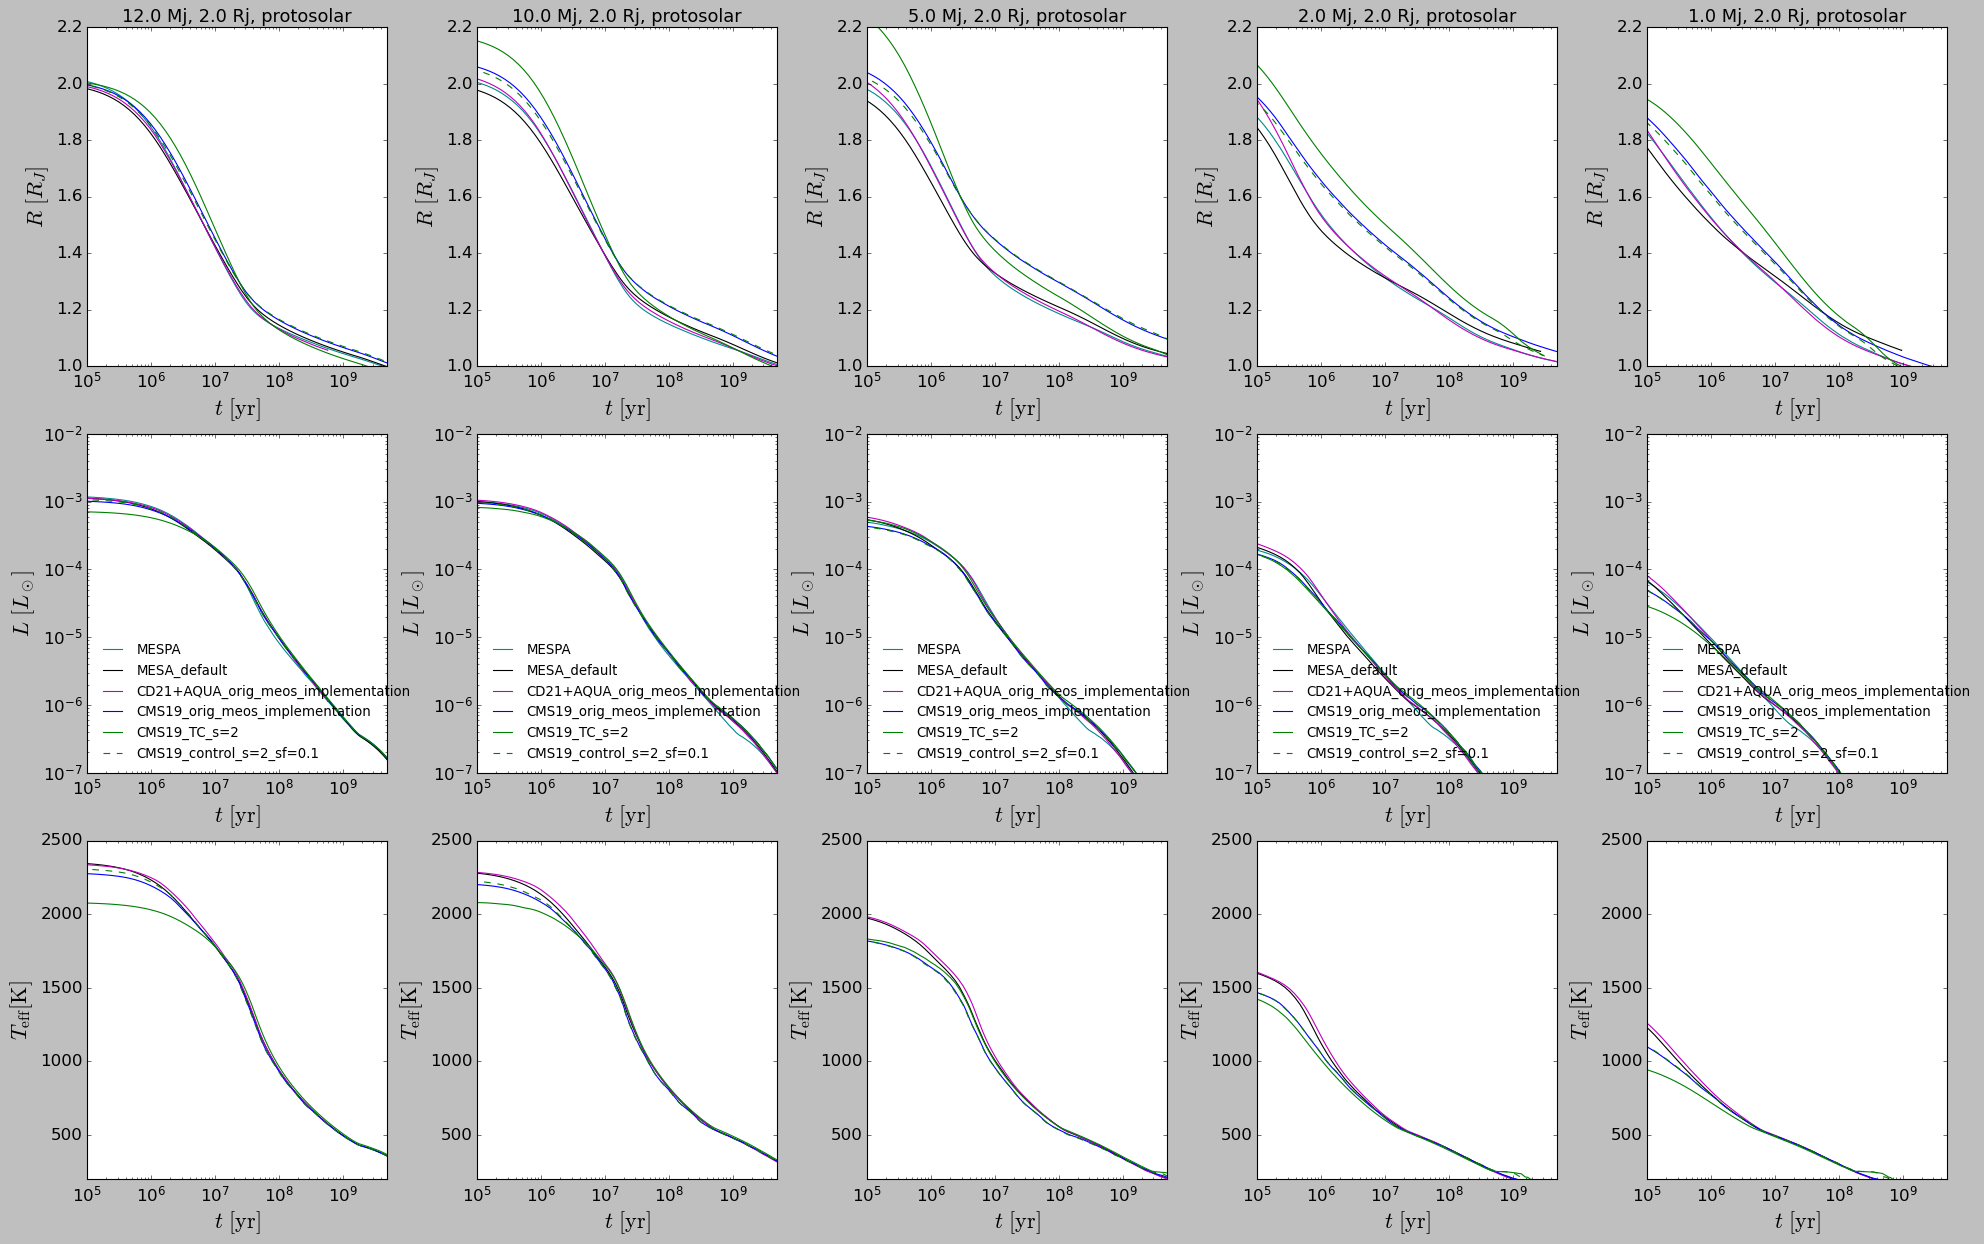

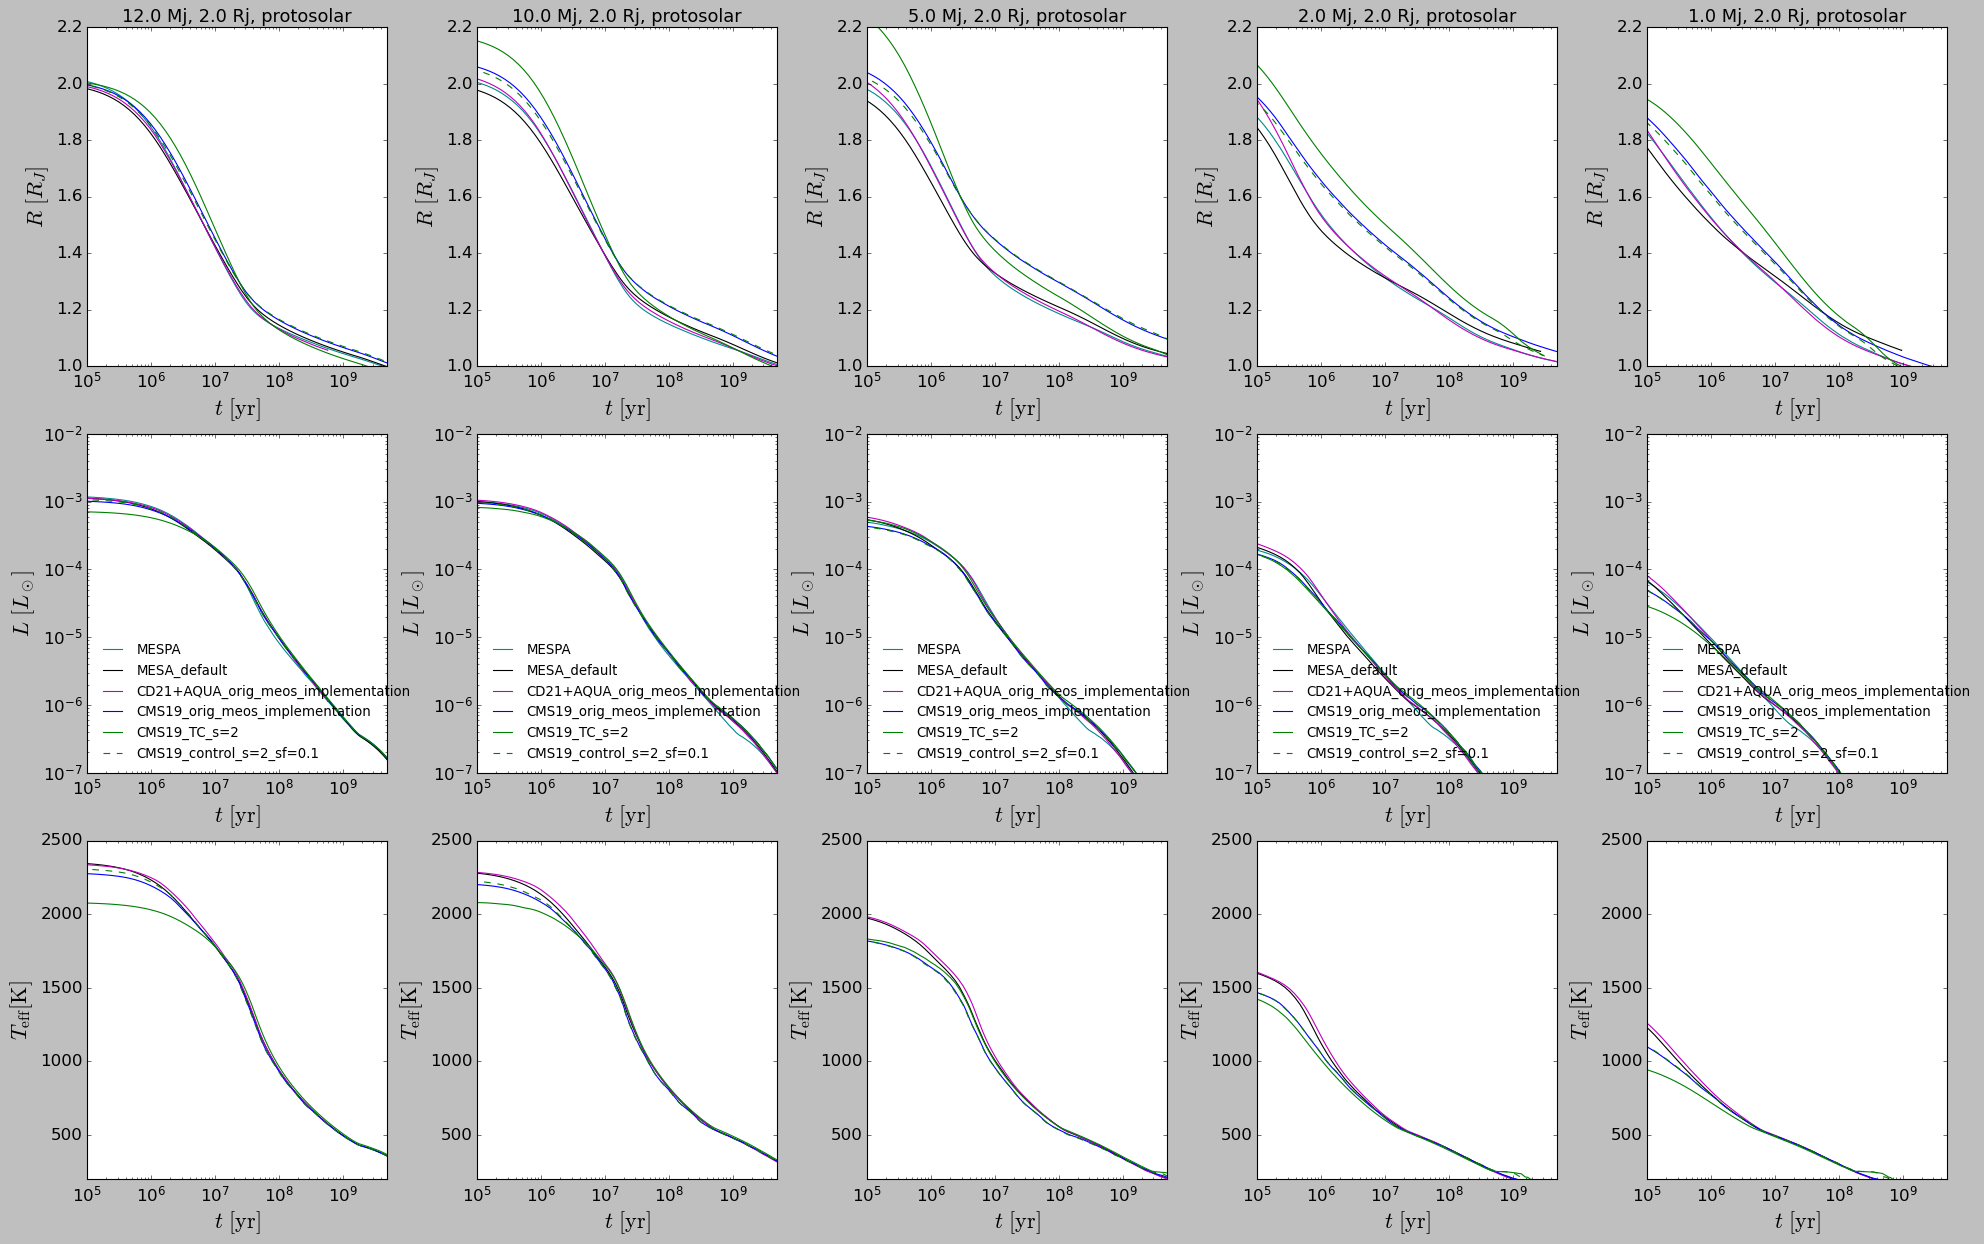

In [7]:
#fig, axes = plt.subplots(3,len(Minit),figsize=(24,16))
fig, axes = plt.subplots(3,len(Minit),figsize=(6*len(Minit),6*3))

for ii in range(len(Minit)):
    axes[0,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
    axes[0,ii].set_ylabel(r"$R\ [R_J]$",fontsize=20)
    axes[1,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
    axes[1,ii].set_ylabel(r"$L\ [L_\odot]$",fontsize=20)
    axes[2,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
    axes[2,ii].set_ylabel(r"$T_{\mathrm{eff}} [\mathrm{K}]$",fontsize=20)
    
    axes[0,ii].set_xscale('log')
    axes[1,ii].set_xscale('log')
    axes[2,ii].set_xscale('log')
    
    axes[1,ii].set_yscale('log')
    axes[0,ii].set_xlim(1.e5,5.e9)
    axes[0,ii].set_ylim(1.,2.2)
    #axes[0,ii].set_ylim(1.,5.1)
    axes[1,ii].set_xlim(1.e5,5.e9)
    axes[1,ii].set_ylim(1.e-7,1.e-2)

    axes[2,ii].set_xlim(1.e5,5.e9)
    axes[2,ii].set_ylim(200,2500)
    
    #axes[2,ii].invert_yaxis()

for ax in np.ravel(axes):
    ax.tick_params(axis='both', which='major', labelsize=15)

for j, m in enumerate(Minit):
    for k, comp in enumerate(comps[0:1]):
        for l, r in enumerate(Rinit[0:1]):
            axes[0,j].set_title("{0} Mj, {1} Rj, {2}".format(m,r,comp),fontsize=16)
            try:     
                history_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/LOGS/planet_5.0Gyr_{0}_Mj_{1}_Rj_{2}_mespa.history".format(m,r,comp)
                
                history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
            
                axes[0,j].plot(history['star_age'],history['radius']*rSuntorJ,color='#008B8B',ls='-')
                axes[1,j].plot(history['star_age'],history['luminosity'],color='#008B8B',ls='-',label='MESPA')
                '''
                profile_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/planet_5.0Gyr_{0}_Mj_{1}_Rj_{2}_mespa.profile".format(m,r,comp)
                
                profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
            
                axes[2,j].plot(profile['logT'],profile['logP']-6,color='#008B8B',ls='-',label='MESPA')
                '''
            except FileNotFoundError:
                print("no mespa for {0}".format(m))
        
            for i,e in enumerate(eos_choices):
    
                try:
                    history_filename = "./eos_{0}/planet_5.0Gyr_{1}_Mj_{2}_Rj_{3}.history".format(e,m,r,comp)
                    history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
        
                    axes[0,j].plot(history['star_age'],history['radius']*rSuntorJ,color=colors[i],ls=ls[i])
                    axes[1,j].plot(history['star_age'],history['luminosity'],color=colors[i],ls=ls[i],label=e)
                    axes[2,j].plot(history['star_age'],history['Teff'],color=colors[i],ls=ls[i])
    
                    #print(e)
                    #print(history['radius']*rSuntorJ)
                    #print(history['luminosity'])
                    '''
                    profile_filename = "./eos_{0}/planet_1.0Gyr_{1}_Mj_{2}.profile".format(e,m,comp)
                    profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
        
                    axes[2,j].plot(profile['logT'],profile['logP']-6,color=colors[i],ls=ls[i],label=e)
                    '''
                    axes[1,j].legend(loc='lower left',frameon=False,fontsize=12)
                except FileNotFoundError:
                    print("no {0}".format(e))
            
plt.subplots_adjust(hspace=0.2,wspace=0.3)
plt.show()
#plt.savefig("../paper_figures/protosolar_model_grid.pdf",bbox_inches='tight')

In [1]:
! ls ../paper_figures/*grid*

../paper_figures/protosolar_model_grid.pdf


In [30]:
# eos names
eos_choices = ['MESA_default','CD21+AQUA_orig_meos_implementation','CMS19_orig_meos_implementation','CMS19_TC_s=1','CD21_Y0275']
comps = ['platowg']

Minit = np.atleast_1d(np.array((1.0)))
Rinit = np.array((2.0,5.0))

age = 5.0e9
agestr = str(np.round(age/1.e9, 1))
print(agestr)

5.0


../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/LOGS/planet_5.0Gyr_1.0_Mj_2.0_Rj_platowg_mespa.history
no MESA_default


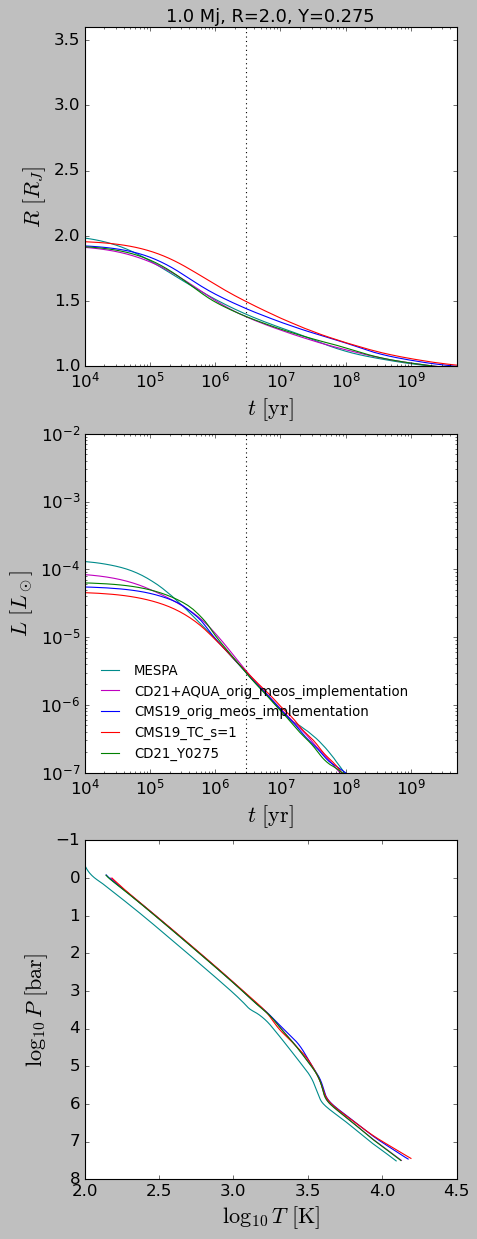

In [21]:
# for Jupiter models

fig, axes = plt.subplots(3,1,figsize=(6,18))
axes[0].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
axes[0].set_ylabel(r"$R\ [R_J]$",fontsize=20)
axes[1].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
axes[1].set_ylabel(r"$L\ [L_\odot]$",fontsize=20)
axes[2].set_xlabel(r"$\log_{10}T\ [\mathrm{K}]$",fontsize=20)
axes[2].set_ylabel(r"$\log_{10}P\ [\mathrm{bar}]$",fontsize=20)
    
axes[0].set_xscale('log')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[0].set_xlim(1.e4,5.e9)
axes[0].set_ylim(1.,3.6)
axes[1].set_xlim(1.e4,5.e9)
axes[1].set_ylim(1.e-7,1.e-2)
    
axes[2].invert_yaxis()

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=15)

for ax in axes[0:2]:
    ax.axvline(3.e6,color='k',ls=':')

for k, comp in enumerate(comps):
    for l, r in enumerate(Rinit[0:1]):
        axes[0].set_title("1.0 Mj, R={0}, Y=0.275".format(r),fontsize=16)
        try:     
            history_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/LOGS/planet_5.0Gyr_1.0_Mj_{0}_Rj_{1}_mespa.history".format(r,comp)
            print(history_filename)
                
            history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
            
            axes[0].plot(history['star_age'],history['radius']*rSuntorJ,color='#008B8B',ls='-')
            axes[1].plot(history['star_age'],history['luminosity'],color='#008B8B',ls='-',label='MESPA')
            
            profile_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/planet_5.0Gyr_1.0_Mj_{0}_Rj_{1}_mespa.profile".format(r,comp)
                
            profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
            
            axes[2].plot(profile['logT'],profile['logP']-6,color='#008B8B',ls='-',label='MESPA')
            
        except FileNotFoundError:
            print("no mespa for {0}".format(m))
        
        for i,e in enumerate(eos_choices):
    
            try:
                history_filename = "./eos_{0}/planet_5.0Gyr_1.0_Mj_{1}_Rj_{2}_customatm.history".format(e,r,comp)
                history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
        
                axes[0].plot(history['star_age'],history['radius']*rSuntorJ,color=colors[i],ls=ls[i])
                axes[1].plot(history['star_age'],history['luminosity'],color=colors[i],ls=ls[i],label=e)
    
                profile_filename = "./eos_{0}/planet_1.0_Mj_{1}_Rj_{2}_customatm.terminationprofile".format(e,r,comp)
                profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
        
                axes[2].plot(profile['logT'],profile['logP']-6,color=colors[i],ls=ls[i],label=e)
    
                axes[1].legend(loc='lower left',frameon=False,fontsize=12)
            except FileNotFoundError:
                print("no {0}".format(e))
            
plt.subplots_adjust(hspace=0.2,wspace=0.3)
plt.show()

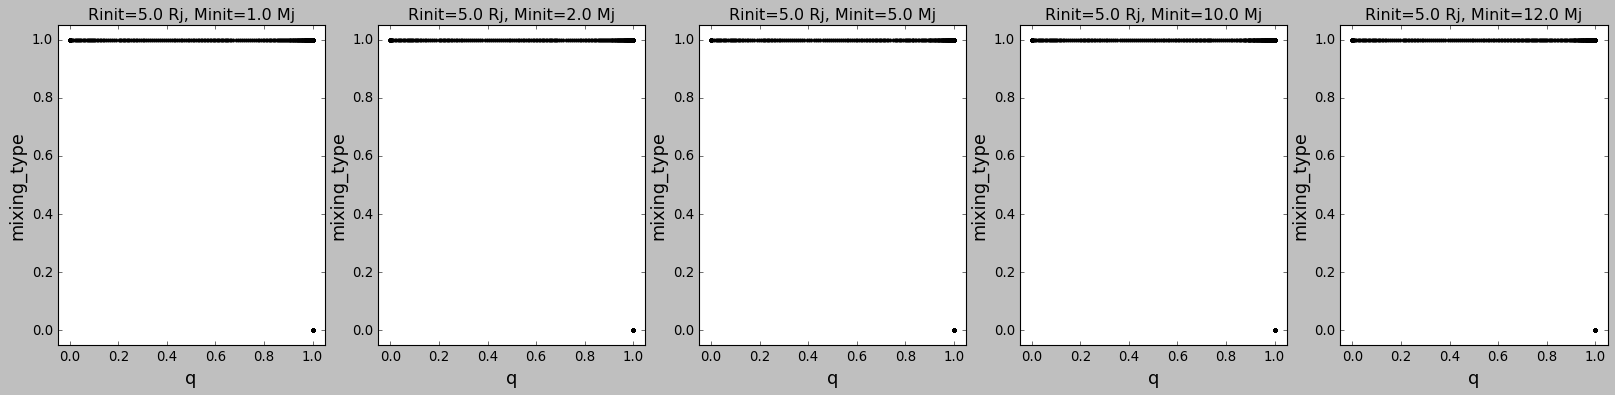

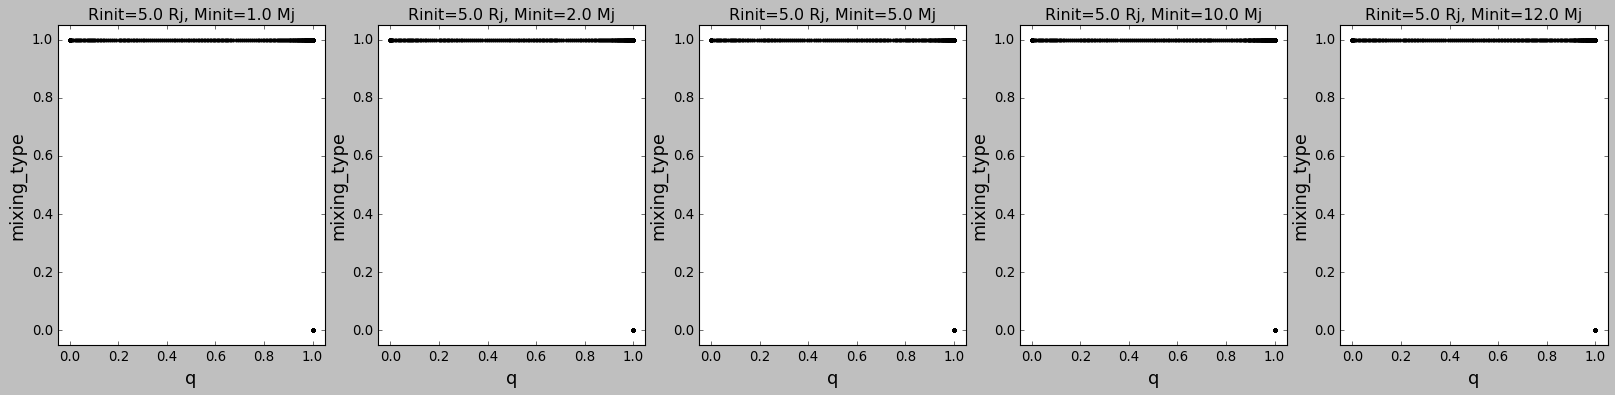

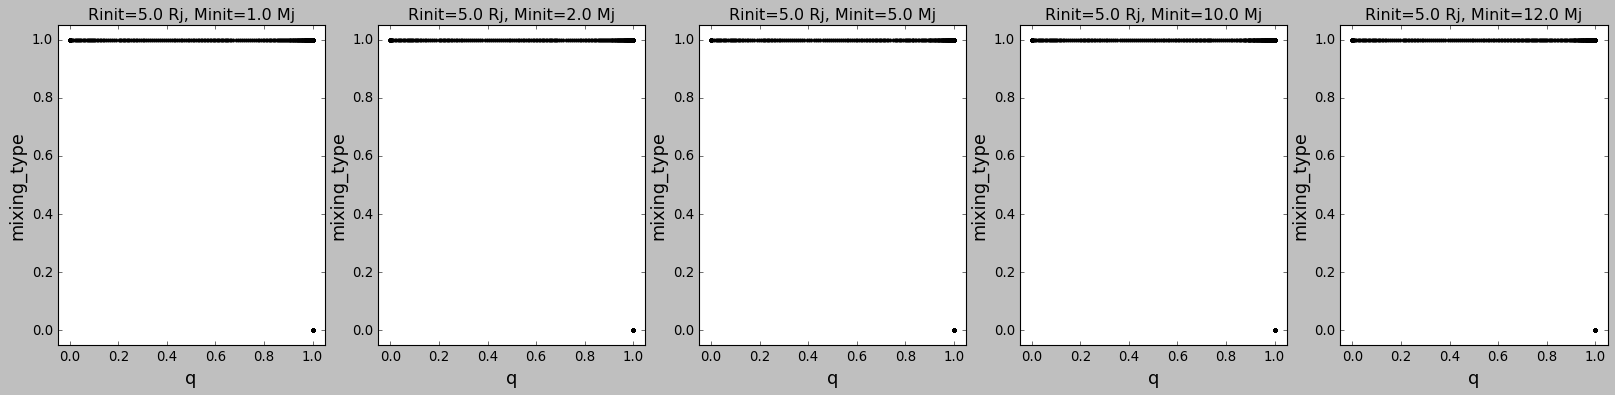

In [17]:
marr = np.array((1.0,2.0,5.0,10.0,12.0))

fig, axes = plt.subplots(1,5,figsize=(25,5))


for i, m in enumerate(marr):
    profile_filename = "./eos_CMS19_orig_meos_implementation/planet_{0}_Mj_5.0_Rj_protosolar.terminationprofile".format(m)
    profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)

    axes[i].plot(profile['q'],profile['mixing_type'],'k.')
    axes[i].set_ylim(-0.05,1.05)
    axes[i].set_xlim(-0.05,1.05)
    axes[i].set_xlabel('q',fontsize=16)
    axes[i].set_ylabel('mixing_type',fontsize=16)
    axes[i].set_title('Rinit=5.0 Rj, Minit={0} Mj'.format(m))

plt.show()
#plt.savefig("/Users/emily/Desktop/mixing_type.png",bbox_inches='tight')
                    